<a href="https://colab.research.google.com/github/larscaspersen/phenoflex_meets_bayes/blob/main/hybridmodel_phenoflex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install -q numpyro==0.14.0 jax==0.4.26 jaxlib==0.4.26 arviz causalgraphicalmodels daft
!pip install -q numpyro jax jaxlib arviz causalgraphicalmodels daft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/56.7 MB 9.2 MB/s eta 0:00:00


In [2]:
# %%
import argparse
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import jax
from jax import random
import jax.numpy as jnp
import arviz as az
import numpyro
from numpyro.contrib.control_flow import scan
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
# Building on numpyro AR2 example: https://num.pyro.ai/en/latest/examples/ar2.html

In [ ]:
def run_inference(model, args, rng_key, dat):
    start = time.time()
    sampler = numpyro.infer.NUTS(model)
    mcmc = numpyro.infer.MCMC(
        sampler,
        num_warmup=args['num_warmup'],
        num_samples=args['num_samples'],
        num_chains=args['num_chains'],
        progress_bar=False if "NUMPYRO_SPHINXBUILD" in os.environ else True,
    )
    mcmc.run(rng_key, **dat)
    mcmc.print_summary()
    az_mcmc = az.from_numpyro(mcmc)
    print("\nMCMC elapsed time:", time.time() - start)
    return mcmc, mcmc.get_samples(), az_mcmc


The standard phenoflex model. Converted from c++ code with claude

I changed the values of E0, E1, A0 and A1 to standard dynamic model. in phenoflex they use the wrong default parameters

In [3]:
# ── Helper functions

#gdh model
def P1z(T: float, Tu: float, Tb: float, Tc: float) -> float:
    """GDH heat-accumulation rate (triangular bell, model 0)."""
    if Tb <= T <= Tu:
        return 0.5 * (1 + np.cos(np.pi + np.pi * (T - Tb) / (Tu - Tb)))
    elif Tu < T <= Tc:
        return 1 + np.cos(np.pi / 2 + np.pi / 2 * (T - Tu) / (Tc - Tu))
    return 0.0

 #alternative heat accumulation model
def P2z(T: float, Tu: float, Delta: float) -> float:
    """Gaussian heat-accumulation rate (model 1)."""
    return np.exp(-((T - Tu) / (2 * Delta)) ** 2)

#transition function (either PDBF to DBF or Py for effective heat accumulation)
def PFcn(T: float, Tf: float, slope: float) -> float:
    """Sigmoid that controls labile→stable chill conversion and heat sensitivity."""
    x = slope * Tf * (T - Tf) / T
    if x >= 17:
        return 1.0
    if x <= -20:
        return 0.0
    sr = np.exp(x)
    return sr / (1 + sr)


def phenoflex(
    temp,
    times,
    yc: float = 40.0,
    zc: float = 190.0,
    s1: float = 0.5,
    E0: float = 4153.5,
    E1: float = 12888.8,
    A0: float = 139500,
    A1: float = 2567000000000000000,
    Tf: float = 4.0,
    slope: float = 1.6,
    Tb: float = 4.0,
    Tu: float = 26.0,
    Tc: float = 36.0,
    Delta: float = 4.0,
    Imodel: int = 0,
    stopatzc: bool = True,
    deg_celsius: bool = True,
    basic_output: bool = True,
) -> dict:
    """
    Python translation of the PhenoFlex C++ / Rcpp model.

    Parameters
    ----------
    temp       : array-like of hourly temperatures
    times      : array-like of corresponding time stamps (hours)
    yc         : chill requirement (stable chill units)
    zc         : heat requirement (GDH or GDD units)
    s1         : slope of PFcn sigmoid for heat sensitivity
    E0, E1     : activation energies for chill pool dynamics
    A0, A1     : pre-exponential factors for chill pool dynamics
    Tf         : base temperature for labile-to-stable chill conversion (°C)
    slope      : steepness of the labile-to-stable sigmoid
    Tb, Tu, Tc : base, optimum, ceiling temperatures for heat model 0 (°C)
    Delta      : half-width for Gaussian heat model 1 (°C)
    Imodel     : 0 = GDH triangular bell, 1 = Gaussian
    stopatzc   : stop simulation once zc is reached
    deg_celsius: True if temperatures are in °C (will be converted to K internally)
    basic_output: True → return only bloomindex; False → return full state arrays

    Returns
    -------
    dict with 'bloomindex' (and optionally 'x', 'y', 'z', 'xs')
    """
    temp = np.asarray(temp, dtype=float)
    times = np.asarray(times, dtype=float)
    N = len(temp)

    x = np.zeros(N)   # labile chill pool
    y = np.zeros(N)   # stable chill pool
    z = np.zeros(N)   # accumulated heat
    xs = np.zeros(N)  # equilibrium labile chill

    # Convert threshold temperatures to Kelvin if needed
    _Tf = Tf + 273.0 if deg_celsius else Tf
    _Tu = Tu + 273.0 if deg_celsius else Tu
    _Tc = Tc + 273.0 if deg_celsius else Tc
    _Tb = Tb + 273.0 if deg_celsius else Tb

    bloomindex = 0

    for i in range(N - 1):
        ti = temp[i] + 273.0 if deg_celsius else temp[i]
        dt = times[i + 1] - times[i]

        # Equilibrium labile chill and rate constant
        xs[i] = A0 / A1 * np.exp(-(E0 - E1) / ti)
        k1 = A1 * np.exp(-E1 / ti)

        # Update labile chill pool (exponential relaxation toward equilibrium)
        x[i + 1] = xs[i] - (xs[i] - x[i]) * np.exp(-k1 * dt)

        # Carry stable chill forward (only modified below if x >= 1)
        y[i + 1] = y[i]

        # Accumulate heat
        if Imodel == 0:
            z[i + 1] = z[i] + P1z(ti, _Tu, _Tb, _Tc) * PFcn(y[i], yc, s1) * dt
        else:
            z[i + 1] = z[i] + P2z(ti, _Tu, Delta) * PFcn(y[i], yc, s1) * dt

        # Convert labile to stable chill when pool is saturated
        if x[i + 1] >= 1.0:
            delta = PFcn(ti, _Tf, slope) * x[i + 1]
            y[i + 1] += delta
            x[i + 1] -= delta

        # Check heat requirement
        if z[i + 1] >= zc:
            bloomindex = i + 2  # +2 for Fortran/R 1-based index convention
            if stopatzc:
                break

    if basic_output:
        return {"bloomindex": bloomindex}
    return {"x": x, "y": y, "z": z, "xs": xs, "bloomindex": bloomindex}

In [4]:
# ── JAX helpers (vectorised, no Python loops) ─────────────────────────────────

def _p1z_jax(T, Tu, Tb, Tc):
    in_lower = (T >= Tb) & (T <= Tu)
    in_upper = (T > Tu) & (T <= Tc)
    val_lower = 0.5 * (1 + jnp.cos(jnp.pi + jnp.pi * (T - Tb) / (Tu - Tb)))
    val_upper = 1 + jnp.cos(jnp.pi / 2 + jnp.pi / 2 * (T - Tu) / (Tc - Tu))
    return jnp.where(in_lower, val_lower, jnp.where(in_upper, val_upper, 0.0))

def _p2z_jax(T, Tu, Delta):
    return jnp.exp(-((T - Tu) / (2 * Delta)) ** 2)

def _pfcn_jax(T, Tf, slope):
    x = slope * Tf * (T - Tf) / T
    sr = jnp.exp(jnp.clip(x, -20, 17))
    return jnp.where(x >= 17, 1.0, jnp.where(x <= -20, 0.0, sr / (1 + sr)))

# ── Soft bloom-date estimator ─────────────────────────────────────────────────

def soft_bloom_hour(z_trace, hours, zc, sharpness=1.0):
    """
    Differentiable approximation of the hour at which z first crosses zc.

    A hard argmax is not differentiable, so we use a softmax over (z - zc).
    As sharpness -> inf this converges to the true crossing point.
    Values of 0.5–2.0 work well in practice.

    Parameters
    ----------
    z_trace   : jnp array (N-1,) — accumulated heat at each time step
    hours     : jnp array (N-1,) — hours[i] is the time at which z_trace[i] was computed
    zc        : heat requirement threshold (scalar, can be a sampled parameter)
    sharpness : controls how peaked the soft-argmax is

    Returns
    -------
    Scalar: differentiable estimate of the bloom hour
    """
    logits  = sharpness * (z_trace - zc)
    # Numerically stable softmax
    logits  = logits - jnp.max(logits)
    weights = jnp.exp(logits)
    weights = weights / jnp.sum(weights)
    return jnp.dot(weights, hours)

# ── Numpyro model ─────────────────────────────────────────────────────────────

def phenoflex_numpyro(
    temp,
    times,
    bloom_doy_obs=None,
    start_doy=0.0,
    Imodel=0,
    deg_celsius=True,
    sharpness=1.0,
):
    """
    Numpyro probabilistic wrapper around PhenoFlex.

    The ONLY observable is the bloom date (day of year). z and y are latent
    state variables that are never observed directly.

    The forward pass accumulates heat (z) over the season. The predicted bloom
    date is the hour at which z crosses zc, converted to day-of-year via
    start_doy. Because argmax is not differentiable we use soft_bloom_hour()
    as a smooth approximation.

    Parameters
    ----------
    temp          : jnp array of hourly temperatures, length N
    times         : jnp array of hours since season start, length N
                    e.g. [0, 1, 2, ..., N-1] for consecutive hourly records
    bloom_doy_obs : observed bloom date as day-of-year (scalar or 1-D array
                    if multiple years are handled outside this function).
                    Pass None for prior predictive / generative mode.
    start_doy     : day-of-year corresponding to times[0].
                    E.g. if the season starts on Nov 1 = DOY 305, pass 305.
    Imodel        : 0 = GDH triangular bell, 1 = Gaussian
    deg_celsius   : True if temperatures arrive in Celsius
    sharpness     : steepness of the soft bloom-date estimator.
                    Increase if the posterior is diffuse; decrease if gradients vanish.
    """

    # ── Priors ────────────────────────────────────────────────────────────────
    yc    = numpyro.sample("yc",    dist.Normal(40.0,  10.0))
    zc    = numpyro.sample("zc",    dist.Normal(190.0, 30.0))
    s1    = numpyro.sample("s1",    dist.Beta(2.0, 2.0))
    E0    = numpyro.sample("E0",    dist.Normal(4153.5, 200.0))
    E1    = numpyro.sample("E1",    dist.Normal(12888.8, 500.0))
    A0    = numpyro.sample("A0",    dist.HalfNormal(139500))
    A1    = numpyro.sample("A1",    dist.HalfNormal(2567000000000000000))
    Tf    = numpyro.sample("Tf",    dist.Normal(4.0,   1.0))
    slope = numpyro.sample("slope", dist.HalfNormal(1.6))
    Tb    = numpyro.sample("Tb",    dist.Normal(4.0,   2.0))
    Tu    = numpyro.sample("Tu",    dist.Normal(26.0,  3.0))
    Tc    = numpyro.sample("Tc",    dist.Normal(36.0,  3.0))
    Delta = numpyro.sample("Delta", dist.HalfNormal(5.0))

    # Convert threshold temperatures to Kelvin
    offset = 273.0 if deg_celsius else 0.0
    _Tf = Tf + offset
    _Tu = Tu + offset
    _Tc = Tc + offset
    _Tb = Tb + offset

    # ── Forward pass via scan ─────────────────────────────────────────────────
    dt = times[1:] - times[:-1]   # shape (N-1,)

    def transition(carry, inputs):
        x_prev, y_prev, z_prev = carry
        ti_raw, dt_i = inputs

        ti = ti_raw + offset

        xs_i = A0 / A1 * jnp.exp(-(E0 - E1) / ti)
        k1   = A1 * jnp.exp(-E1 / ti)

        x_new = xs_i - (xs_i - x_prev) * jnp.exp(-k1 * dt_i)
        y_new = y_prev

        heat_rate = _p1z_jax(ti, _Tu, _Tb, _Tc) if Imodel == 0 else _p2z_jax(ti, _Tu, Delta)
        z_new = z_prev + heat_rate * _pfcn_jax(y_prev, yc, s1) * dt_i

        # Labile -> stable chill conversion
        delta   = _pfcn_jax(ti, _Tf, slope) * x_new
        convert = jnp.where(x_new >= 1.0, 1.0, 0.0)
        y_new   = y_new + convert * delta
        x_new   = x_new - convert * delta

        return (x_new, y_new, z_new), z_new

    init   = (jnp.array(0.0), jnp.array(0.0), jnp.array(0.0))
    inputs = (temp[:-1], dt)

    _, z_trace = scan(transition, init, inputs)
    # z_trace[i] = accumulated heat after processing hour i+1

    # ── Predicted bloom date ──────────────────────────────────────────────────
    # times[1:] are the hours at which each z value was recorded
    bloom_hour     = soft_bloom_hour(z_trace, times[1:], zc, sharpness=sharpness)
    bloom_doy_pred = numpyro.deterministic(
        "bloom_doy_pred",
        start_doy + bloom_hour / 24.0,
    )

    # ── Observation noise ─────────────────────────────────────────────────────
    # Bloom phenology observations carry real uncertainty from observer error,
    # the definition of first-flower, spatial variability, etc.
    # A few days of SD is typical for field phenology data.
    sigma = numpyro.sample("sigma", dist.HalfNormal(3.0))  # days

    # ── Likelihood ────────────────────────────────────────────────────────────
    if bloom_doy_obs is not None:
        # Inference mode: condition on observed bloom date
        numpyro.sample("bloom_doy", dist.Normal(bloom_doy_pred, sigma),
                       obs=bloom_doy_obs)

In [ ]:
#read csv file from github repository


In [ ]:
def crop_model(init=None,n_timesteps=100,L_t=None, w_t=None):
    # Define prior distributions
    Is = numpyro.sample("Is", dist.Exponential(1))*10
    epsilon = numpyro.sample("epsilon", dist.Exponential(1))/1000 # (kg/MJ)
    k = numpyro.sample("k", dist.Exponential(2))
    p = numpyro.sample("p", dist.Exponential(2))
    s = numpyro.sample("s", dist.Exponential(1))*10 # m2/kg

    def transition(carry, _):
        # get values from previous period
        L_prev, w_prev = carry

        # Calcualte Intercepted PAR (MJ m-2 d-1)
        Ipar = Is*(1-jnp.exp(-k*L_prev))
        # Calcualte change in biomass
        dw = Ipar*epsilon
        # Calculate change in Leafareaindex
        dL = s*p*dw
        # Update Leafareaindex and biomass
        L_t = numpyro.sample("L_t", dist.Normal(L_prev+dL, .1))
        # L_t = numpyro.deterministic("L_t", L_prev+dL) # determinstic model
        # L_t = L_prev+dL # determinstic model

        # Update biomass (kg/sqm)
        w_t = numpyro.sample('w_t',dist.Normal(w_prev+dw,.1))
        # w_t = numpyro.deterministic('w_t',w_prev+dw) #determinstic model

        # Update what is carried to the next iternation
        carry = (L_t, w_t)
        return carry, None

    # Inference mode
    if L_t is not None:
        timesteps = jnp.arange(L_t.shape[0] - 1)
        init = (L_t[0], w_t[0])
        with numpyro.handlers.condition(data={"L_t": L_t[1:], "w_t":w_t[1:]}):
            scan(transition, init, timesteps)
    # Generative mode
    else:
        timesteps = jnp.arange(n_timesteps)
        scan(transition, init, timesteps)



In [ ]:
# Run the model forward (i.e. generate artifical data)
num_data = 50 # number of time period
rng_key = jax.random.PRNGKey(1) # random seed
t = jnp.arange(0, num_data) # array for t

# Set parameters, same as in lecture slides from Thomas Gaiser
coefTrue = {
          'Is':1.8, # (scaled in model by *10, was 18 MJ m-2 d-1 in slides)
          'epsilon':3,
          'k':0.7,
          'p':0.5,
          's':2, # (in model scaled to m2/kg, was 0.02 m2/g in slides)
          }
condition_model = numpyro.handlers.condition(crop_model, data=coefTrue)
prior_predictive = Predictive(condition_model, num_samples=1)

# set start values (same as used in lecture slides)
L_zero = 0.2
w_zero = 0.1/1000 # (kg/sqm)

# Sample Y from model
rng_key, rng_key_ = random.split(rng_key)
prior_samples = prior_predictive(rng_key_,init=(L_zero, w_zero), n_timesteps=num_data)

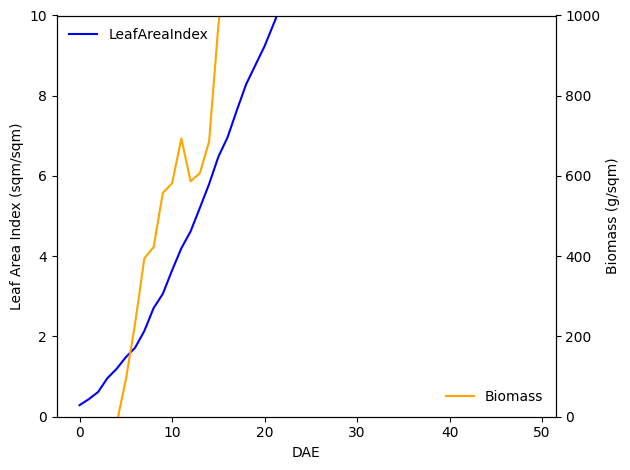

In [ ]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(t, prior_samples['L_t'][0,:], label='LeafAreaIndex',color='blue');
ax2.plot(t, prior_samples['w_t'][0,:]*1000, label='Biomass',color='orange');
ax1.legend(loc='upper left', frameon=False)
ax2.legend(loc='lower right', frameon=False)

ax1.set_ylabel('Leaf Area Index (sqm/sqm)')
ax2.set_ylabel('Biomass (g/sqm)')
ax1.set_xlabel('DAE')


ax1.set_ylim(0,10)
ax2.set_ylim(0,1000)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [ ]:
# Get "observations" from one draw of the prior
L_t = prior_samples['L_t'][0]
w_t = prior_samples['w_t'][0]

true_Is = prior_samples['Is'][0]
true_epsilon = prior_samples['epsilon'][0]
true_k = prior_samples['k'][0]
true_p = prior_samples['p'][0]
true_s = prior_samples['s'][0]

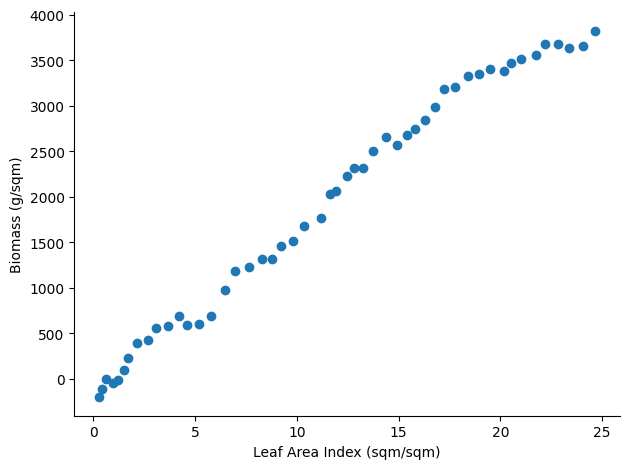

In [ ]:
fig, ax = plt.subplots()
ax.scatter(L_t,w_t*1000)

ax.set_xlabel('Leaf Area Index (sqm/sqm)')
ax.set_ylabel('Biomass (g/sqm)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()




In [ ]:
# Estimate the model using PP, taking the "observed" data
# (i.e. the one generated before)
dat = {'L_t':L_t,
       'w_t':w_t,
      'init':None}

args = {}
args['num_warmup'] = 1000
args['num_samples'] = 1000
args['num_chains'] = 2
model = crop_model

mcmc, mcmc_samples, az_mcmc = run_inference(crop_model, args, rng_key, dat)

/tmp/ipykernel_603/719121536.py:4: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(
sample: 100%|██████████| 2000/2000 [00:03<00:00, 506.83it/s, 127 steps of size 2.64e-02. acc. prob=0.95]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        Is      3.03      1.30      2.77      1.13      4.94    853.17      1.00
   epsilon      3.06      1.32      2.80      1.17      4.97    778.55      1.00
         k      0.85      0.17      0.83      0.58      1.12    916.04      1.00
         p      0.70      0.45      0.59      0.14      1.33    674.66      1.00
         s      1.45      0.96      1.18      0.28      2.79    591.87      1.00

Number of divergences: 0

MCMC elapsed time: 21.62435293197632


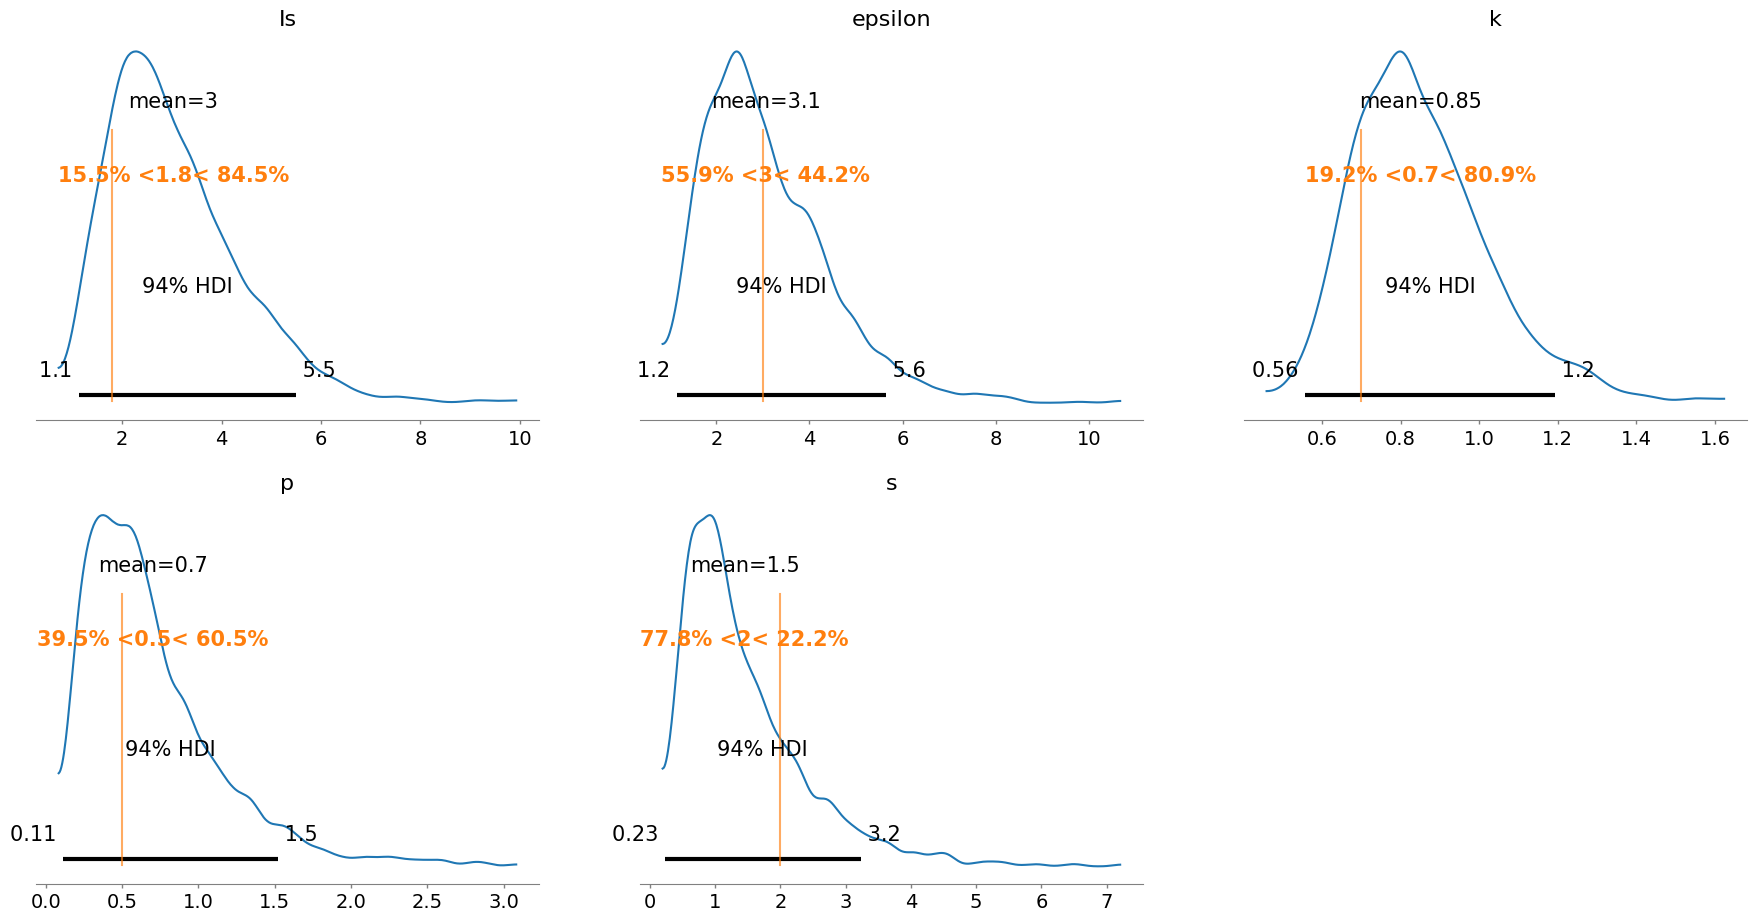

In [ ]:
# Plot posterior estimates
az.plot_posterior(az_mcmc,
            ref_val=[
                true_Is,
                true_epsilon,
                true_k,
                true_p,
                true_s
            ]);